# Example 5: Computing p-values with CV-Aware Pretrained Lasso

This notebook demonstrates how to use `PPL_SI_CV` and `PPL_SI_CV_randj` to compute
selective p-values after data-driven hyperparameter selection via cross-validation.

The CV-aware inference conditions on the full CV selection event:

$$\mathcal{Z}_{\rm CV} = \mathcal{Z}_1 \cap \mathcal{Z}_2 \cap \mathcal{Z}_3$$

where $\mathcal{Z}_2$ encodes the Step 1 CV winner ($\lambda_{\rm sh}$) and $\mathcal{Z}_3$
encodes the Step 2 CV winner $(\rho, \lambda_K)$.

In [1]:
import numpy as np
import sys
sys.path.append('..')
from ppl_si import generate_synthetic_data, PPL_SI_CV, PPL_SI_CV_randj

## 1. Generate Synthetic Data

In [3]:
np.random.seed(42)

p = 300
num_sh = 10
num_inv = 5
K = 5
n_list = [100, 100, 100, 100, 100]
true_beta_sh = 0.5
n = sum(n_list)
nK = n_list[-1]
X_list, Y_list, true_betaK, Sigma_list = generate_synthetic_data(
    p=p,
    num_sh=num_sh,
    num_inv=num_inv,
    K=K,
    n_list=n_list,
    true_beta_sh=true_beta_sh,
    itc=0.5,
    Gamma=0.05
)

print(f"Number of groups: {len(X_list)}")
print(f"Feature dimension: {p}")
print(f"Target sample size: {n_list[-1]}")

Number of groups: 5
Feature dimension: 300
Target sample size: 100


## 2. Set CV Hyperparameter Grids

In [4]:
lambda_sh = np.sqrt(2 * np.log(p)*n)
lambda_K = np.sqrt(2 * np.log(p)*nK)

Lambda = [i * lambda_sh for i in [0.75, 1, 1.25]]
lamK_list = [i * lambda_K for i in [ 0.75, 1, 1.25 ]]
rho_list = [0.25, 0.5, 0.75]
Lambda_tilde = [(r, lK) for r in rho_list for lK in lamK_list]

n_folds = 5
threshold = 20
num_segments = 26

print(f"Lambda grid (lambda_sh):  {Lambda}")
print(f"Lambda_tilde grid (rho, lambda_K):")
for Phi in Lambda_tilde:
    print(f"  rho={Phi[0]}, lambda_K={Phi[1]}")
print(f"n_folds: {n_folds}")
print(f"num_segments: {num_segments}")

Lambda grid (lambda_sh):  [np.float64(56.64254268651888), np.float64(75.52339024869184), np.float64(94.4042378108648)]
Lambda_tilde grid (rho, lambda_K):
  rho=0.25, lambda_K=25.331315173097952
  rho=0.25, lambda_K=33.775086897463936
  rho=0.25, lambda_K=42.21885862182992
  rho=0.5, lambda_K=25.331315173097952
  rho=0.5, lambda_K=33.775086897463936
  rho=0.5, lambda_K=42.21885862182992
  rho=0.75, lambda_K=25.331315173097952
  rho=0.75, lambda_K=33.775086897463936
  rho=0.75, lambda_K=42.21885862182992
n_folds: 5
num_segments: 26


## 3. Compute p-values for All Selected Features

In [5]:
p_values = PPL_SI_CV(
    X_list=X_list,
    Y_list=Y_list,
    Lambda=Lambda,
    Lambda_tilde=Lambda_tilde,
    Sigma_list=Sigma_list,
    n_folds=n_folds,
    threshold=threshold,
    num_segments=num_segments,
)

if p_values is not None:
    print(f"Number of selected features: {len(p_values)}")
    print("\nFeature index and p-values:")
    for j, p_val in p_values:
        print(f"Feature {j}: true_betaK[{j}] = {true_betaK[j]:.4f}, p-value = {p_val:.4f}")
else:
    print("No features selected")

Number of selected features: 12

Feature index and p-values:
Feature 0: true_betaK[0] = 0.5826, p-value = 0.0007
Feature 1: true_betaK[1] = 0.5000, p-value = 0.0004
Feature 2: true_betaK[2] = 0.5000, p-value = 0.0000
Feature 3: true_betaK[3] = 0.5000, p-value = 0.0016
Feature 4: true_betaK[4] = 0.5000, p-value = 0.0001
Feature 5: true_betaK[5] = 0.5000, p-value = 0.0000
Feature 6: true_betaK[6] = 0.5000, p-value = 0.1693
Feature 7: true_betaK[7] = 0.5000, p-value = 0.0000
Feature 8: true_betaK[8] = 0.5000, p-value = 0.0002
Feature 9: true_betaK[9] = 0.5000, p-value = 0.0227
Feature 10: true_betaK[10] = 0.5000, p-value = 0.0000
Feature 18: true_betaK[18] = 0.0000, p-value = 0.5837


## 4. Compute p-value for a Random Selected Feature

In [6]:
j, p_value_rand = PPL_SI_CV_randj(
    X_list=X_list,
    Y_list=Y_list,
    Lambda=Lambda,
    Lambda_tilde=Lambda_tilde,
    Sigma_list=Sigma_list,
    n_folds=n_folds,
    threshold=20,
    num_segments=num_segments,
)


if p_value_rand is not None:
    print(f"Random feature: {j} - true_betaK[{j}] = {true_betaK[j]:.4f}, p-value = {p_value_rand:.4f}")
else:
    print("No features selected")

Random feature: 1 - true_betaK[1] = 0.5000, p-value = 0.7266


## 5. Analysis

In [7]:
if p_values is not None:
    alpha = 0.05
    significant_features = [(j, p) for j, p in p_values if p <= alpha]

    print(f"Significance level: {alpha}")
    print(f"Number of selected features: {len(p_values)}")
    print(f"Number of significant features: {len(significant_features)}")

    if len(significant_features) > 0:
        print("\nSignificant features:")
        for j, p_val in significant_features:
            print(f"Feature {j}: true_betaK[{j}] = {true_betaK[j]:.4f}, p-value = {p_val:.4f}")

Significance level: 0.05
Number of selected features: 12
Number of significant features: 10

Significant features:
Feature 0: true_betaK[0] = 0.5826, p-value = 0.0007
Feature 1: true_betaK[1] = 0.5000, p-value = 0.0004
Feature 2: true_betaK[2] = 0.5000, p-value = 0.0000
Feature 3: true_betaK[3] = 0.5000, p-value = 0.0016
Feature 4: true_betaK[4] = 0.5000, p-value = 0.0001
Feature 5: true_betaK[5] = 0.5000, p-value = 0.0000
Feature 7: true_betaK[7] = 0.5000, p-value = 0.0000
Feature 8: true_betaK[8] = 0.5000, p-value = 0.0002
Feature 9: true_betaK[9] = 0.5000, p-value = 0.0227
Feature 10: true_betaK[10] = 0.5000, p-value = 0.0000


## 6. Pivot Uniformity Test

Test that p-values from `PPL_SI_CV_randj` are uniformly distributed under the null hypothesis (no true signal, $s=0$).  
Under $H_0$, the selective p-value should satisfy $p \sim \text{Uniform}(0,1)$.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import statsmodels.api as sm

def run_PPL_CV(max_iter=200):
    p = 300
    num_sh = 0      # No shared signal (null hypothesis)
    num_inv = 0     # No individual signal (null hypothesis)
    K = 5
    n_list = [100, 100, 100, 100, 100]
    true_beta_sh = 0
    Gamma = 0.1

    lambda_sh = 0.5 * np.sqrt(np.log(p)*n)
    lambda_K = 0.5 * np.sqrt(np.log(p)*nK)
    
    Lambda = [i * lambda_sh for i in [0.75, 1, 1.25]]
    lamK_list = [i * lambda_K for i in [ 0.75, 1, 1.25 ]]
    rho_list = [0.25, 0.5, 0.75]
    Lambda_tilde = [(r, lK) for r in rho_list for lK in lamK_list]

    n_folds = 5
    threshold = 20
    num_segments = 24

    p_sel_list = []
    total_false_positives_detected = 0
    total_false_positives_rejected = 0
    alpha = 0.05

    i = 0 

    while i < max_iter:
        if (i+1) % 50 == 0:
            print(f"Iteration {i + 1}/{max_iter}")

        X_list, Y_list, true_betaK, Sigma_list = generate_synthetic_data(
            p=p,
            num_sh=num_sh,
            num_inv=num_inv,
            K=K,
            n_list=n_list,
            true_beta_sh=true_beta_sh,
            Gamma=Gamma,
            itc=0.1,
        )

        j, p_sel = PPL_SI_CV_randj(
            X_list=X_list,
            Y_list=Y_list,
            Lambda=Lambda,
            Lambda_tilde=Lambda_tilde,
            Sigma_list=Sigma_list,
            n_folds=n_folds,
            threshold=20
        )

        if p_sel is not None:
            total_false_positives_detected += 1
            if p_sel <= alpha:
                total_false_positives_rejected += 1
            p_sel_list.append(p_sel)
            i+=1

    if total_false_positives_detected > 0:
        FPR = total_false_positives_rejected / total_false_positives_detected
        print(f"\nFalse positive rate (alpha={alpha}): {FPR:.4f}")
    else:
        print("\nNo features selected in any iteration.")

    if len(p_sel_list) > 0:
        stat, p_val = stats.kstest(p_sel_list, 'uniform')
        print(f"KS test: statistic={stat:.4f}, p-value={p_val:.4f}")

        plt.rcParams.update({'font.size': 18})
        plt.figure(figsize=(10, 8))
        grid = np.linspace(0, 1, 101)
        plt.plot(grid, sm.distributions.ECDF(np.array(p_sel_list))(grid), 'r-', linewidth=6, label='PPL-SI CV p-value')
        plt.plot([0, 1], [0, 1], 'k--', label='Uniform')
        plt.xlabel('x')
        plt.ylabel('ECDF')
        plt.title('CV-Aware Pretrained Lasso — Pivot Uniformity')
        plt.legend()
        plt.tight_layout()
        plt.show()

    return p_sel_list

Iteration 50/500
Iteration 100/500
Iteration 150/500
Iteration 200/500
Iteration 250/500
Iteration 300/500
Iteration 350/500
Iteration 400/500
Iteration 450/500
Iteration 500/500

False positive rate (alpha=0.05): 0.0520
KS test: statistic=0.0358, p-value=0.5315


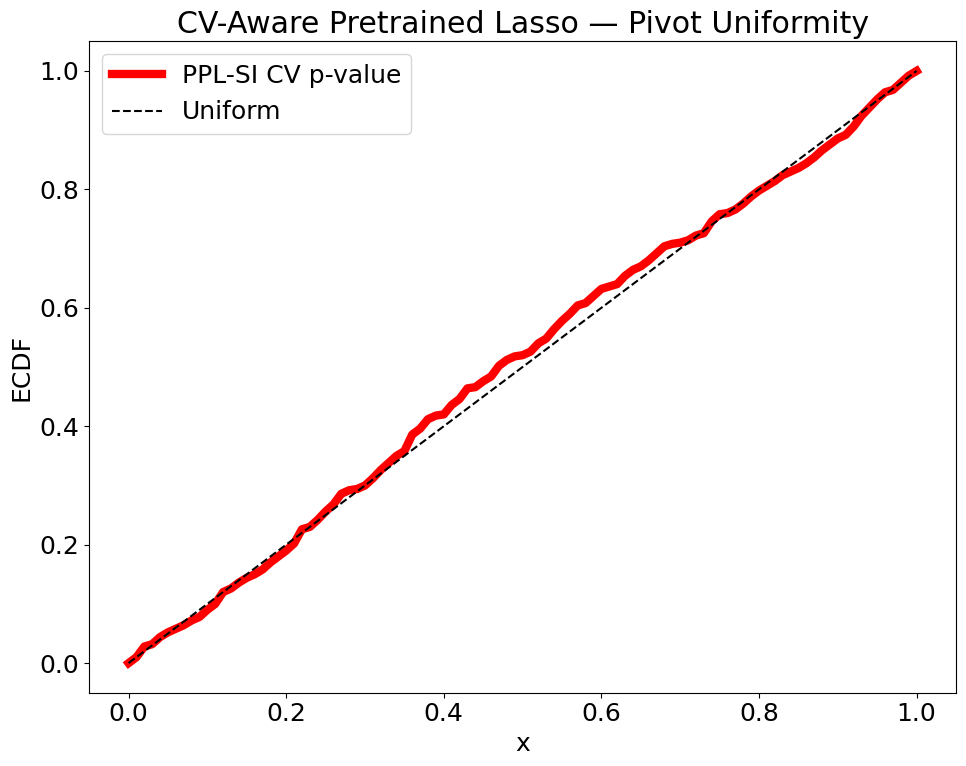

[0.6991810125192592,
 0.30475043992585205,
 0.8350710836565899,
 0.5440951497918778,
 0.7772430845805494,
 0.16404678686702634,
 0.8903029844950736,
 0.8777245472023536,
 0.6263076930617391,
 0.20105263237893464,
 0.7441542541581619,
 0.46376000580964205,
 0.8294212036630337,
 0.26817399778078066,
 0.6683925319853401,
 0.8980921719011824,
 0.670709889876667,
 0.8734392618701108,
 0.472108100649262,
 0.506599513766149,
 0.3137583157023567,
 0.45788112365483613,
 0.6492988065816441,
 0.42015886038872957,
 0.019545817272740518,
 0.7672216112848557,
 0.7899352586009832,
 0.03800677476782077,
 0.054811645854355495,
 0.4705353743494749,
 0.24834279769856038,
 0.3520939419447231,
 0.5950605464900178,
 0.34755569633756433,
 0.04031840307197021,
 0.815083773963174,
 0.1687585274656485,
 0.029816015601130275,
 0.650389095019617,
 0.7151361621544634,
 0.3757909323044806,
 0.918007895349908,
 0.9194816594443413,
 0.5141593245433598,
 0.336962935012441,
 0.5277815927711642,
 0.05208396593518503,
 0

In [9]:
run_PPL_CV(max_iter=500)